<!-- <img src="../code/Resources/cropped-SummerWorkshop_Header.png">  -->

<h1 align="center">Workshop 1: Tutorial on behavioral states </h1> 
<h3 align="center">Summer Workshop on the Dynamic Brain</h3> 
<h3 align="center">Thursday, August 24th, 2026</h3> 
<h4 align="center">Day 2</h4> 

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> During the lecture, we learned about behavioral states and how they affect the processing of sensory stimuli and, consequently, motor outputs. In this workshop, we will explore how to define behavioral states and investigate both external and internal markers of state changes reflected through behavior as well as neural activity. We will examine these phenomena in mice as they perform a context-dependent decision-making task.

<p> During the task, the mice are engaged in behavior that requires them to process contextual cues, interact with their environment, and display a variety of behavioral state sequences. Meanwhile, Neuropixels electrodes record brain-wide spiking activity across the cortex and several hippocampal, striatal and thalamic areas. The behavioral task, therefore, offers an opportunity to study the dynamics of spiking activity during various behavioral states and aids in understanding the behavioral dynamics of task performance and engagement.     
</div>

<center><img src="/root/capsule/code/resources/DR_task_description.png" style="width:1500px; height:500px; max-width:none;"> </center>

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> The Dynamic Routing (DR) dataset (refer to <a href="https://allenswdb.github.io/physiology/ephys/dynamic-routing/dynamic-routing-background.html">DR Databook</a>) consists of brain-wide recordings of neural activity measured using six Neuropixels probes from twelve mice trained to perform a context-dependent decision-making task. Throughout the session, behavior video cameras and running sensors continuously track various body parts, running speed, and pupil size of the subjects.

<p> In this go/no-go task, mice are required to selectively respond to either visual or auditory stimuli presented in alternating trial blocks. Each block, signaled by instruction trials, lasts 10 minutes. During visual blocks, mice must respond only to the visual target stimulus (VIS+), while during auditory blocks, they must respond only to the auditory target stimulus (AUD+). In both blocks, they must suppress responses to non-target stimuli (AUD-, VIS-). The blocks alternate between visual and auditory modalities for a total of six blocks, and mice earn water rewards by correctly reporting (licking the water spout) when the target stimulus appears in the currently rewarded modality.  
</div>

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The DR dataset is stored as <a href="https://www.nwb.org/">Neurodata Without Borders (NWB)</a> files, a standardized format for storing neurophysiology data. To access these files, we will use the Python library <a href="https://pynwb.readthedocs.io/en/stable/tutorials/index.html">pynwb</a>, which is designed for reading and writing NWB data. We begin by importing this library along with other standard Python libraries for data preprocessing and plotting. 

</div>

In [1]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb


# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


##  Load the Dynamic Routing experiment from NWB

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Let’s examine the NWB file structure of a single experimental session and explore the metadata recorded for each behavioral trial. All experimental sessions share the same NWB structure.
</div>

In [2]:
root = Path("/root/capsule/data/dynamicrouting_datacube")

example_session_ids = [
                        "759434_2025-02-04", "713655_2024-08-09", "743199_2024-12-05", 
                        "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24"
                        "667252_2023-09-28", "715710_2024-07-16", "708016_2024-04-29"
                    ]


session_id = example_session_ids[1]

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb.zarr"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr


In [3]:
# access the session data with pynwb - should take about a minute

session = pynwb.read_nwb(nwb_path)

# Quick reference of the NWB file structure
# Important groups include: units, trials, intervals, and processing 
session

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.17525
2,14.19192
3,14.20858
,timestamps
id,
0,NaN
1,14.40125
2,14.41791


In [4]:
# Get trials dataframe and look at a few rows

trials = session.trials[:]
trials.tail(7)

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
508,6158.82071,6164.35866,6158.82071,6160.28857,6160.330000,6160.830000,6160.40536,6161.32289,NaN,NaN,NaN,6161.350300,6164.386180,sound2,NaN,5,vis,508,82.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,False,False,False,False
509,6165.22615,6170.76400,6165.22615,6166.71063,6166.771530,6167.271960,6166.82745,6167.74483,NaN,NaN,NaN,6167.772380,6170.791560,vis2,0.5,5,vis,509,83.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False
510,6174.28360,6179.82163,6174.28360,6175.76835,6175.809680,6176.309680,6175.88498,6176.80238,NaN,NaN,NaN,6176.829970,6179.849145,sound1,NaN,5,vis,510,84.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,False,False,False
511,6180.73900,6186.27699,6180.73900,6182.20691,6182.267840,6182.768277,6182.32372,6183.25784,6182.90753,6182.89689,6182.92426,6183.285355,6186.304570,vis1,0.0,5,vis,511,85.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
512,6187.89507,6193.43299,6187.89507,6189.36296,6189.423835,6189.940945,6189.47969,6190.41378,NaN,NaN,NaN,6190.441365,6193.460555,vis2,0.0,5,vis,512,86.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False
513,6194.06691,6199.62151,6194.06691,6195.55143,6195.612360,6196.112785,6195.66821,6196.58566,6196.13529,6196.13434,6196.15195,6196.613195,6199.649065,vis1,0.5,5,vis,513,87.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
514,6200.20533,6205.74332,6200.20533,6201.69007,6201.750830,6202.251240,6201.80676,6202.72414,NaN,NaN,NaN,6202.751670,6205.770870,vis2,0.0,5,vis,514,88.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False


<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
How well does the mouse modulate its responses to target stimuli based on the context block? We address this by quantifying its response rate for each target stimulus.
</div>

In [5]:
hit_rate = np.sum(trials.is_hit)/np.sum(trials.is_go)
false_alarm_rate = np.sum(trials.is_false_alarm)/np.sum(trials.is_nogo) 
print(f"Hit rate: {hit_rate:.2f}")
print(f"False alarm rate: {false_alarm_rate:.2f}")

Hit rate: 0.95
False alarm rate: 0.12


## Mouse behavioral performance over the session

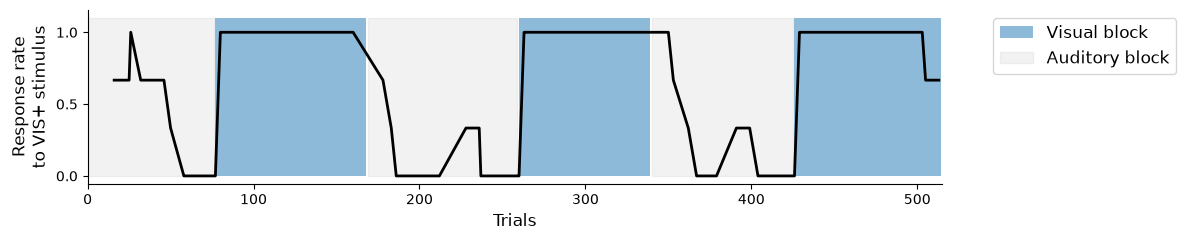

In [6]:
# response rates to target 
vis_target_response_rate =  trials[trials.is_vis_target].is_response.rolling(3).mean()

fig, ax = plt.subplots(figsize = (12, 2.5), sharex = True, sharey = True)
ax.plot(vis_target_response_rate, color = 'k',  lw = 2)

# add block information 
vis_block = trials.is_vis_rewarded
ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')
    

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)

ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response rate\nto VIS+ stimulus', fontsize = 12)
plt.tight_layout()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.1:</b> Re-write the code to evaluate response rates to the auditory target stimulus.
</p> </div>

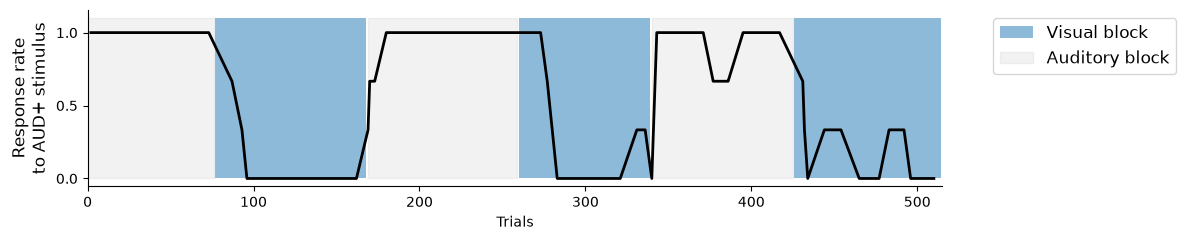

In [ ]:
# Blank coding cell to work out Task 1.1  

# # response rates to target 
# aud_target_response_rate = ...

# fig, ax = plt.subplots(figsize = (12, 2.5), sharex = True, sharey = True)
# ax.plot( .... )

# # add block information 
# vis_block = trials.is_vis_rewarded
# ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
# ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')
    

# # formatting
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.set_xlim(0, len(trials))
# ax.set_yticks([0, 0.5, 1])
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)

# ax.set_xlabel('Trials')
# ax.set_ylabel('Response rate\nto AUD+ stimulus', fontsize = 12)
# plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF;">

Visual and auditory hit rates provide separate measures of performance in each context. The **response modulation index (RMI)** combines these measurements into a single metric, allowing us to quantify the mouse's context-dependent response strategy.

$$
\mathrm{RMI} =
\frac{R_{\mathrm{vis+}} - R_{\mathrm{aud+}}}
{R_{\mathrm{vis+}} + R_{\mathrm{aud+}}}
$$

where $R_{\mathrm{vis+}}$ and $R_{\mathrm{aud+}}$ are the rolling response rates for visual and auditory target stimuli, respectively.

</div>

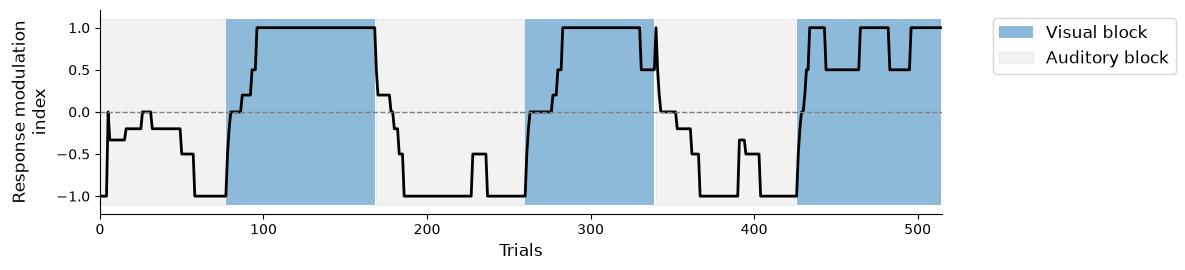

In [8]:
# response modulation index 

# Select target trials and sort by index for consistency
subset_trials = (
    trials.loc[trials.is_vis_target | trials.is_aud_target]
    .sort_index()
    .copy()
)

window = 3  # Define the rolling window size

# Response rate across the most recent visual target trials
vis_target_response_rate = (
    subset_trials[subset_trials.is_vis_target].is_response
    .astype(float)
    .rolling(window=window, min_periods=1)
    .mean()
)

# Response rate across the most recent auditory target trials
aud_target_response_rate = (
    subset_trials[subset_trials.is_aud_target].is_response
    .astype(float)
    .rolling(window=window, min_periods=1)
    .mean()
)

# Place rate estimates back onto the full target-trial sequence, Fill NaN values by propagating
trials["vis_target_response_rate"] = vis_target_response_rate.reindex(trials.index).ffill().fillna(0)
trials["aud_target_response_rate"] = aud_target_response_rate.reindex(trials.index).ffill().fillna(0)


# Response Modualtion index = (vis_target_response_rate - aud_target_response_rate) / (vis_target_response_rate + aud_target_response_rate)
# calculate denominator for response modulation index
denominator = (
    trials["vis_target_response_rate"]
    + trials["aud_target_response_rate"]
)

trials["response_modulation_index"] = np.where(
    denominator > 0,
    (
        trials["vis_target_response_rate"]
        - trials["aud_target_response_rate"]
    ) / denominator,
    np.nan,
)

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(trials["response_modulation_index"], color="k", lw=2)
ax.plot([0, len(trials)], [0, 0], color="gray", lw=1, ls="--")

# add block information 
vis_block = trials.is_vis_rewarded
ax.fill_between(vis_block.index, -1.1, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
ax.fill_between(vis_block.index, -1.1, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel("Trials", fontsize = 12)
ax.set_ylabel("Response modulation\nindex", fontsize = 12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
The mouse modulates its responses according to the current context block, indicating that it transitions between distinct behavioral states. 
</div>

## Identifying behavioral states based on visual inspection

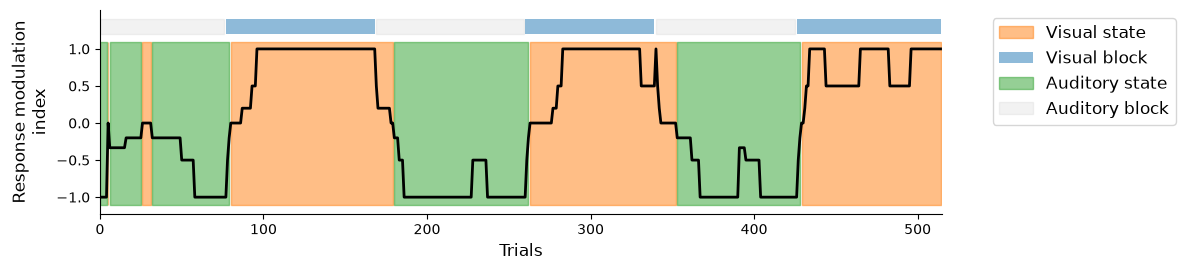

In [9]:
# response rate thresholds for each modality
response_threshold = 0
behavioral_state = trials["response_modulation_index"] >= response_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot( trials["response_modulation_index"], color = 'k',  lw = 2)

ax.fill_between(behavioral_state.index, -1.1, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 1, alpha=0.5, label = 'Visual block')

ax.fill_between(behavioral_state.index, -1.1, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')


# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response modulation\nindex', fontsize = 12) 
ax.legend(bbox_to_anchor=(1.05, 1), fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
When the mouse’s state changes, does it affect other aspects of its behavior too? To answer this, let’s look beyond their task performance and examine additional variables including running speed and pupil size.
</div>

## Do spontaneous behaviors reflect behavioral state?

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
To study on the mouse's internal state, let’s focus our analysis on the <b>quiescent period</b>, i.e., the interval before stimulus presentation. 
</div>

In [10]:
session.processing['behavior']

Name,/processing/behavior/facemap_front_camera/data
Type,zarr.core.Array
Data type,float32
Shape,"(460263, 500)"
Chunk shape,"(14384, 32)"
Order,C
Read-only,True
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.ConsolidatedMetadataStore
Chunk store type,zarr.storage.DirectoryStore
No. bytes,920526000 (877.9M)


<center><img src="/root/capsule/code/resources/behavioral_features.png" style="width:1350px; height:310px; max-width:none;"> </center>

In [11]:
def get_trialwise_values(x, timestamps, start, stop):
    """
    Extracts trial-wise summary statistics of different behaviors (mean or median) from a time-aligned signal.

    Parameters:
    - x : array-like
        Signal values (e.g., neural data or behavioral measurements).
    - timestamps : array-like
        Time points corresponding to each value in x.
    - start : array-like
        Start times for each trial.
    - stop : array-like
        Stop times for each trial.

    Returns:
    - values : list
        List of mean or median values for each trial window.
    """
    return np.array([np.nanmean(x[np.logical_and(s1 <= timestamps, timestamps <= s2)]) 
            for s1, s2 in zip(start, stop)])

def get_facial_feature(part_name, facial_features_df):
    """
    Extracts and preprocesses the Y-coordinate of a facial feature from a dataframe.

    Parameters:
    ----------
    part_name : str
        The name of the facial feature/part.
    facial_features_df : pandas.DataFrame

    Returns:
    -------
    y : np.ndarray
        Cleaned and interpolated Y-coordinate time series of the feature.
    """

    # Extract likelihood (confidence of detection) for the feature
    confidence = facial_features_df[f'{part_name}_likelihood']

    # Extract temporal norm
    temporal_norm = facial_features_df[f'{part_name}_temporal_norm']

    # Flip Y-coordinate relative to image height
    y = 492 - facial_features_df[f'{part_name}_y']

    # Mask low-confidence or high-temporal-norm points as NaN (to discard unreliable or jumpy detections)
    y[(confidence < 0.99) | 
      (temporal_norm > np.nanmean(temporal_norm) +  2*np.nanstd(temporal_norm))] = np.nan

    # center and remove outliers
    y_centered = y - np.nanmean(y)
    y_abs_centered = np.abs(y_centered)
    y_centered[y_abs_centered > np.nanmean(y_abs_centered) + 2*np.std(y_abs_centered) ]  = np.nan

    # Interpolate missing values (NaNs) to create a continuous time series
    y_interp = pd.Series(y_centered).ffill().bfill().to_numpy()

    return y_interp

In [12]:
# access trials table and get the start and stop times
trial_start = trials.stim_start_time.values - 1.5 
trial_stop = trials.stim_start_time.values 

behavior_data = {}

# facial expressions: 
facial_features_df = session.processing['behavior']['lp_side_camera'][:]
feature_timestamps = facial_features_df['timestamps'].values.astype('float')


ear = get_facial_feature('ear_base_l', facial_features_df)
behavior_data['ear'] = get_trialwise_values(ear, feature_timestamps, trial_start, trial_stop)

nose = get_facial_feature('nose_tip', facial_features_df)
behavior_data['nose'] = get_trialwise_values(nose, feature_timestamps, trial_start, trial_stop)

jaw = get_facial_feature('jaw', facial_features_df)
behavior_data['jaw'] = get_trialwise_values(jaw, feature_timestamps, trial_start, trial_stop)

whisker_pad = get_facial_feature('whisker_pad_l_side', facial_features_df)
behavior_data['whiskers'] = get_trialwise_values(whisker_pad, feature_timestamps, trial_start, trial_stop)

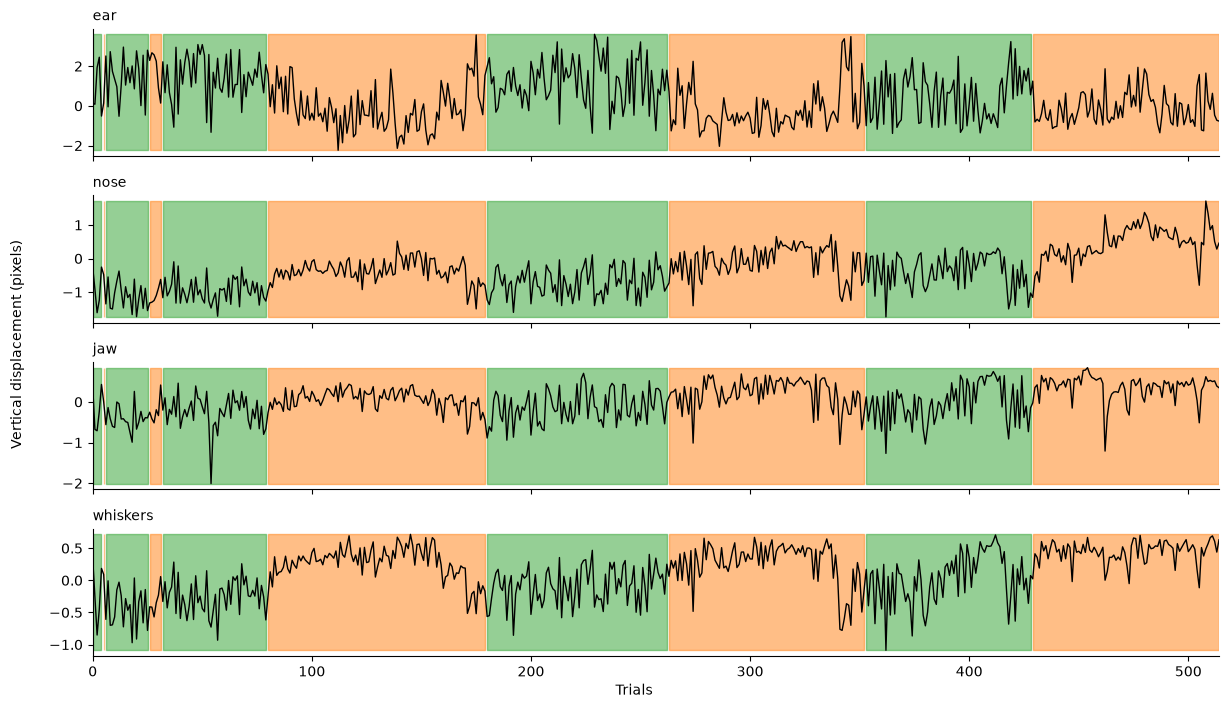

In [ ]:
# lets first look at the facial features
keys_to_plot = ['ear', 'nose', 'jaw', 'whiskers']

fig, ax = plt.subplots(4, 1, figsize = (12, 7), sharex = True)

for i, key in enumerate(keys_to_plot):
    ax[i].plot(trials.index, behavior_data[key], color = 'k', lw = 1)
    ax[i].set_title(key, fontsize = 10, loc = 'left')
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_xlim(trials.index[0], trials.index[-1])

    
    # Get min and max of this behavior trace
    min_val = np.nanmin(behavior_data[key])
    max_val = np.nanmax(behavior_data[key])

    # add state information 
    
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')

fig.text(0.5, 0.00, 'Trials', ha='center')
fig.text(-0.02, 0.5, 'Vertical displacement (pixels)', va='center', rotation='vertical')
plt.tight_layout()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.2:</b> How do running speed and pupil size vary across behavioral states? Can you plot it? 
</p> </div>

In [ ]:
# Blank coding cell to work out Task 1.2

# running speed
running_data = session.processing['behavior']['running_speed']
running_timestamps = running_data.timestamps[:]
running_speed = running_data.data[:]
running_speed = pd.Series(running_speed).interpolate(limit_direction='both').to_numpy() 

# get trialwise values for running speed
# behavior_data['running_speed'] = ## write your code here

# pupil area
pupil_data = session.processing['behavior']['eye_tracking']
pupil_timestamps = pupil_data.timestamps[:]
pupil_area = pupil_data.pupil_area[:]
pupil_area = pd.Series(pupil_area).interpolate(limit_direction='both').to_numpy() 

# get trialwise values for pupil area
# behavior_data['pupil_area'] = ## write your code here

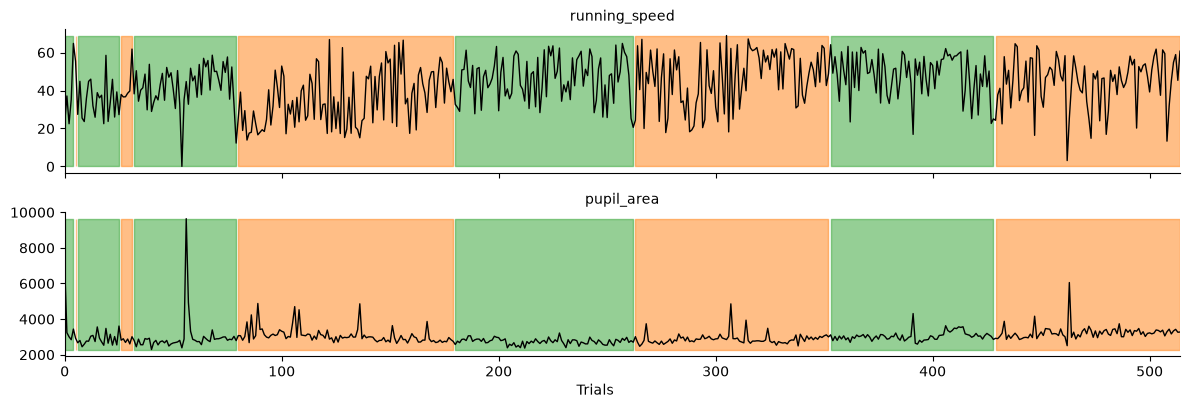

In [ ]:
# Blank coding cell to work out Task 1.2

# keys_to_plot = ## fill in the keys

for i, key in enumerate(keys_to_plot):
    ax[i].plot(trials.index, behavior_data[key], color = 'k', lw = 1)
    ax[i].set_title(key, fontsize = 10, loc = 'left')
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_xlim(trials.index[0], trials.index[-1])

    
    # Get min and max of this behavior trace
    min_val = np.nanmin(behavior_data[key])
    max_val = np.nanmax(behavior_data[key])

    # add state information 
    
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')

fig.text(0.5, 0.00, 'Trials', ha='center')
fig.text(-0.02, 0.5, 'Vertical displacement (pixels)', va='center', rotation='vertical')
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>
While defining behavioral states by thresholding the response modulation index is a useful starting point, it is incomplete. There are several additional variables that could provide more nuanced insights into the mouse's behavioral state, but we have not incorporated them into our definition.
</p>

<p>
In this example, the response modulation index captures the mouse's context preference, but it does not distinguish between successful task engagement and poor performance. More generally, threshold-based definitions of behavioral state often require manually selected cutoffs, which may work well for one subject or dataset but fail to generalize across animals. How, then, can we systematically characterize behavioral states across many mice?
</p>

<p>
In the remainder of this workshop, we will explore more sophisticated methods for defining behavioral states that integrate multiple behavioral features to provide a richer, more reliable description of each mouse's behavioral profile.
</p>

</div>

## Examine covariation between behavioral features

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
First, we'll learn how to make sense of a more complex view of the behavioral information. Instead of looking at just one behavioral variable, we will examine multiple variables simultaneously to gain a better understanding of what's going on. As we have seen, some of these behavior variables correlate with the task-engaged behavioral state and also correlate with each other. Let's create a visualization to see how the different behavioral variables are correlated.

</div>


In [16]:
# Convert behavior_data dictionary to dataframe for ease of use 
behavior_df = pd.DataFrame(behavior_data)
behavior_df.head(7)

,ear,nose,jaw,whiskers,running_speed,pupil_area
0,0.133465,-0.267715,0.373126,0.332965,23.099572,6959.737914
1,0.081053,-0.913409,-0.676667,-0.260415,37.117426,3239.302947
2,1.924991,-1.614430,-0.709831,-0.851483,22.501092,3004.855885
3,2.449824,-1.242968,-0.236218,-0.449283,35.196670,2842.635555
4,-0.512931,-0.255123,0.428931,0.185256,64.799488,3439.184146
5,0.139870,-0.479911,0.002372,0.092429,55.423635,2925.313986
6,2.512434,-1.353199,-0.559814,-0.607728,27.432272,2669.711419


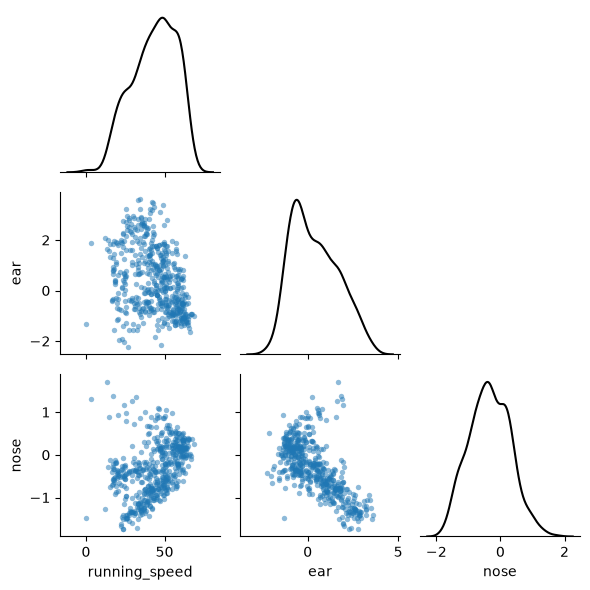

In [ ]:
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Initialize the PairGrid 
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots 
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.5,
    linewidth=0,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method="scott",
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()
plt.show()

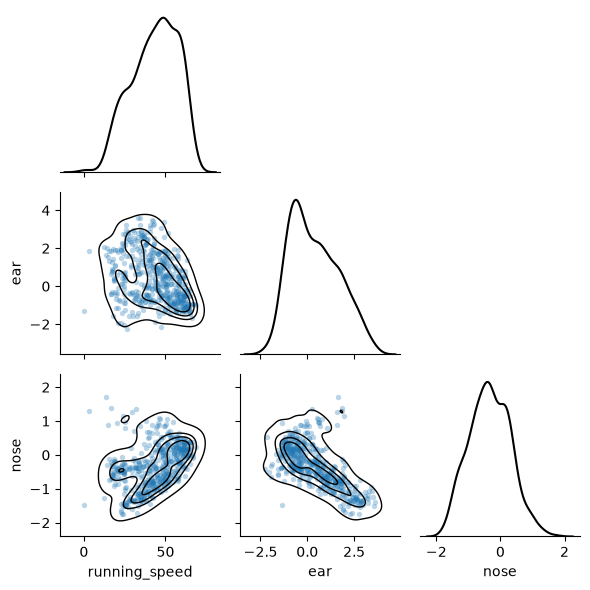

In [ ]:
# Variables to include in the pairwise plot


# Bandwidth method for KDE
width = "scott"

# Initialize the PairGrid 
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots 
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.3,
    linewidth=0,
)

# Overlay 2D kernel density contours
g.map_lower(
    sns.kdeplot,
    bw_method=width,
    levels=5,      # Number of contour levels
    color="k",     # Black contour lines
    linewidths=1,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method=width,
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()

plt.show()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<b>Task 1.3</b>: In the pairwise density plots, try playing around with the option 'bw_method' by setting it to scalar values between [0.15, 1]. How does this affect the density plots? Do you still think there are only 2 states? Do this below. 
</div>

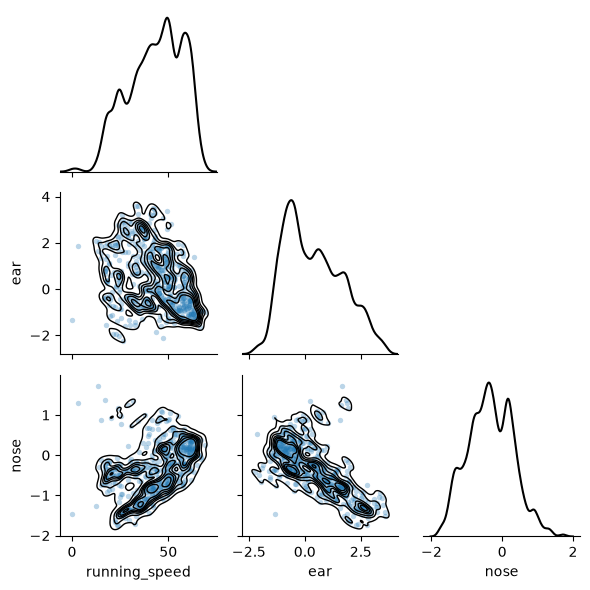

In [ ]:
# Blank coding cell to work out Task 1.3
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Bandwidth method for KDE
# width = ## change this value to adjust the smoothness of the KDE contours

# Initialize the PairGrid with only the lower triangle
# g = sns.PairGrid(
#     behavior_df,
#     vars=variables,
#     corner=True,
#     diag_sharey=False,
# )

# Plot scatterplots in the lower triangle
# g.map_lower(
#     sns.scatterplot,
#     s=15,
#     alpha=0.3,
#     linewidth=0,
# )

# Overlay 2D kernel density contours
# g.map_lower(
#     sns.kdeplot,
#     bw_method=width,
#     levels=8,      # Number of contour levels
#     color="k",     # Black contour lines
#     linewidths=1,
# )

# Plot 1D kernel density estimates along the diagonal
# g.map_diag(
#     sns.kdeplot,
#     bw_method=width,
#     legend=False,
#     color = 'k'
# )

# # Formatting
# g.figure.set_size_inches(6, 6)
# g.figure.tight_layout()

# plt.show()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
This visualization broadly showed two states that mapped well to our previous state definitions. But playing around with the density plots may have raised some doubts that there were only two states.

Does every peak deserve a behavior state? How can we define state boundaries while incorporating all behavior variables? Are there other behavior states?

Moreover, when determining behavioral states, we are dealing with data that changes over time, where the current state may depend on the current observation and also on the previous state. How do we incorporate time information?!
</div>

## !! Whiteboard session !! 

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h4>Multivariate definition of behavioral states</h4>

<p>The density plots suggest there may be multiple underlying behavioral states. One approach to identifying these states is to use unsupervised clustering methods to group similar observations across multiple behavioral variables, revealing distinct patterns that may correspond to different states.</p>

<p>K-means and Gaussian Mixture Models (GMMs) are two such clustering methods. While K-means assigns each data point to a single cluster with a deterministic assignment, GMMs allow data points to belong to multiple clusters with varying degrees of membership probabilities, making them more flexible than K-means. Unlike K-means, GMMs can model clusters with different shapes and orientations, providing a more realistic representation of the underlying structure.</p>

<p>Let’s see how we can draw a link from K-means clustering to GMMs. By making this connection, we will introduce a new tool to your toolbox: the concept of a mixture model, which seeks to maximize the likelihood of the observed data under a combination of probability distributions.</p>
</div>

<style>
.jp-RenderedMarkdown blockquote {
  border-left: 3px solid #000;
  border-radius: 3px;
  padding: 8px 12px;
  background: #F0FAFF;
  margin: 0.5em 0;
}
.jp-RenderedMarkdown blockquote p {
  margin: 0.5em 0;
}
</style>

> ### K-means and Gaussian Mixture Models
>
> First, lets sort out our notation:
>
> **Constants**
>
> - N - number of data points.
> - K - number of clusters/components.
>
> **Data**
>
> - $\mathbf{X} = \{x_n\}_{n=1}^{N}$ where $x_n \in \mathbb{R}^{D}$ is the $n^{\text{th}}$ data point.
>
> **Latent Variables**
>
> - $\mathbf{Z} = \{z_n\}_{n=1}^{N}$ where $z_n \in \{1, \ldots, K\}$ is the cluster assignment for the $n^{\text{th}}$ data point.
>
> **Parameters**
>
> - $\boldsymbol{\Theta} = \{\mu_k\}_{k=1}^{K}$ where $\mu_k \in \mathbb{R}^{D}$ is the mean of the $k$-th cluster.
>
> #### K-Means
>
> K-Means is an algorithm for estimating the latent variables, $\mathbf{Z}$, and the parameters, $\boldsymbol{\Theta}$, given the data, $\mathbf{X}$. The algorithm alternates between two steps:
>
> 1. **Assign** each data point to the closest cluster:
>
> $$
> z_{n} = \underset{k \in \{1,\ldots,K\}}{\arg\min} \lVert x_{n} - \mu_{k} \rVert_{2}
> $$
>
> 2. **Update** the parameters to the mean of the assigned data points:
>
> $$
> \mu_{k} = \frac{1}{N_{k}}\sum_{n = 1}^{N} w_{n,k} x_{n}
> $$
>
> where
>
> $$
> w_{n,k} =
> \begin{cases}
> 1 & \text{if } z_n = k \\
> 0 & \text{otherwise}
> \end{cases},
> \qquad
> N_k = \sum_{n=1}^{N} w_{n,k}.
> $$
>
> We can think of $w_{n,k}$ as the *weight* or *responsibility* that data point $n$ assigns to cluster $k$.

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"">
<p><b>Question:</b> From this perspective, isn't it weird that K-Means assigns all the weight to the nearest cluster, even for points that are right on the boundary between two clusters? 
</div>

<style>
.jp-RenderedMarkdown blockquote.em-blue-box {
  border-left: 3px solid #000;
  border-radius: 3px;
  padding: 8px 12px;
  background: #F0FAFF;
  margin: 0.5em 0;
}
.jp-RenderedMarkdown blockquote.em-blue-box p {
  margin: 0.5em 0;
}
</style>

> #### Gaussian Mixture Model (GMM)
>
> A GMM is a probabilistic model that specifies a joint distribution over data and latent variables given parameters:
>
> $$
> \begin{aligned}
> p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})
> &= \prod_{n=1}^{N} p(x_n \mid z_n, \boldsymbol{\Theta}) \, p(z_n \mid \boldsymbol{\Theta}) \\
> &= \prod_{n=1}^{N} \mathcal{N}(x_n \mid \mu_{z_n}, I) \, \mathrm{Cat}(z_n \mid \tfrac{1}{K}\boldsymbol{1}_K)
> \end{aligned}
> $$
>
> It is a **generative model** in that we can sample latent variables and data points from the model. In one dimension, it looks like this:
>
> <center><img src="../code/resources/GMM.png" width="400" height="250" style="max-width: 100%; height: auto;"> </center>
>
> The nice thing about thinking in terms of generative models is that it allows us to extend the model in various ways. For example:
>
> 1. We can let the clusters have **anisotropic covariance matrices** by changing the model to:
>
> $$
> p(x_n \mid z_n, \boldsymbol{\Theta}) = \mathcal{N}(x_n \mid \mu_{z_n}, \Sigma_{z_n})
> $$
>
> where now the parameter set consists of both means and covariance matrices, $\boldsymbol{\Theta} = \{\mu_k, \Sigma_k\}_{k=1}^{K}$.
>
> Then the assignment and update steps change to:
>
> $$
> \begin{aligned}
> w_{n,k} &= \frac{\mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \mathcal{N}(x_n \mid \mu_j, \Sigma_j)} \\
> \Sigma_k &= \frac{1}{N_k}\sum_{n=1}^{N} w_{n,k}(x_n - \mu_k)(x_n - \mu_k)^\top
> \end{aligned}
> $$
>
> 2. We can allow for unbalanced classes by changing the model to:
>
> $$
> p(z_n \mid \boldsymbol{\Theta}) = \mathrm{Cat}(z_n \mid \boldsymbol{\pi})
> $$
>
> where now the parameter set includes cluster probabilities, $\boldsymbol{\Theta} = \{\mu_k, \Sigma_k, \pi_k\}_{k=1}^{K}$ such that $\sum_k \pi_k = 1$.
>
> Then the assignment and update steps change to:
>
> $$
> \begin{aligned}
> w_{n,k} &= \frac{\pi_k\mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j\mathcal{N}(x_n \mid \mu_j, \Sigma_j)} \\
> \pi_k &= \frac{N_k}{N}
> \end{aligned}
> $$
>


<style>
.jp-RenderedMarkdown blockquote.em-blue-box {
  border-left: 3px solid #000;
  border-radius: 3px;
  padding: 8px 12px;
  background: #F0FAFF;
  margin: 0.5em 0;
}
.jp-RenderedMarkdown blockquote.em-blue-box p {
  margin: 0.5em 0;
}
</style>

> #### Expectation-Maximization (EM)
>
> Instead, consider the following tweak to K-Means. Instead of setting the weight to 0 or 1, set it to:
>
> $$
> w_{n,k} = \frac{\mathcal{N}(x_n \mid \mu_k, I)}{\sum_{j=1}^{K} \mathcal{N}(x_n \mid \mu_j, I)}
> $$
>
> where $\mathcal{N}(x \mid \mu, \Sigma)$ denotes the **probability density function (pdf)** of a point $x_n$ under a **multivariate normal distribution** with mean $\mu$ and covariance $\Sigma$.
>
> Then the resulting algorithm corresponds to the expectation-maximization (EM) algorithm. EM is a generic algorithm for estimating the parameters of latent variable models. In this case, it estimates the parameters $\boldsymbol{\Theta}$ of a Gaussian mixture model.
> #### What are K-Means and EM really doing?
>
> From this probabilistic perspective, we can now understand K-Means and EM as two closely related estimation algorithms. It turns out that K-Means is doing coordinate ascent on the joint probability, $p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})$, alternating between assigning data points to clusters and updating the parameters. By contrast, EM is performing coordinate ascent on a *lower bound* on the marginal probability, $p(\mathbf{X} \mid \boldsymbol{\Theta}) = \sum_{\mathbf{Z}} p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})$. 

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h2> How should we incorporate time? </h2>
<p> But its not simply enough to fit a Gaussian distribution to our behavioral data. While GMMs are a powerful tool for clustering and learning probabilistic associations in our data,they assume that each data point is independent of others. When determining behavioral states, we are dealing with data that changes over time, where the current state may depend on the current observation and also on the previous state. A choice which fulfills the goal are state-space models. 
    
<p> State space models are a framework used to understand and predict complex systems that change over time. They are particularly useful when dealing with dynamic processes that might not be directly observable but can still influence the observed data. Sound familiar? 
    
<p> The state-space model that we will be exploring in this workshop is the Gaussian hidden Markov model (HMM). 

</div>

<style>
.jp-RenderedMarkdown blockquote {
  border-left: 3px solid #000;
  border-radius: 3px;
  padding: 8px 12px;
  background: #F0FAFF;
  margin: 0.5em 0;
}
.jp-RenderedMarkdown blockquote p {
  margin: 0.5em 0;
}
</style>

> #### Gaussian Hidden Markov Model (HMM)
>
> A Gaussian HMM introduces the notion of dynamics to state determination. The behavior of an HMM is fully determined by three probabilities:
>
> 1. **Transition probability** $p(z_{t+1} \mid z_t)$, the probability of $z_{t+1}$ given its previous state $z_t$. We can describe the transition probability by a $K \times K$ transition matrix. The $(i,j)^{\text{th}}$ element denotes the probability of transitioning from state $i$ to state $j$.
>
> 2. **Emission probability** $p(x_t \mid z_t)$, the probability of the observation $x_t$ given its hidden state $z_t$. Specifically, for a Gaussian HMM, emission probabilities take the form:
>
> $$
> p(x_t \mid z_t, \boldsymbol{\Theta}) = \mathcal{N}(x_t \mid \mu_{z_t}, \Sigma_{z_t})
> $$
>
> where the emission parameters $\boldsymbol{\Theta} = \{(\mu_k, \Sigma_k)\}_{k=1}^{K}$ include the means and covariances for each of the $K$ discrete states.
>
> 3. **Initial state distribution** $p(z_1)$.

<h4 align="left">Hidden Markov models</h4> 

<center><img src="../code/resources/gHMM.png" width="300" height="400"; max_width = None> </center>

## Dynamax and JAX

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
<p>So, lets try out HMM models! First, let's take a moment to import our minmal set of packages. This might take a few minutes. 
    
<p><b> Dynamax </b> is a package created in collaboration between the Linderman lab and Google building around a <b>JAX engine</b>. JAX is a functional language which handles the backend for fast computation while presenting similarly to numpy. This means that you'll want to carry state along between calls. </p> 
  
<p><b> Dynamax </b>implements a variety of Gaussian HMMs with different constraints on the parameters (e.g. diagonal, spherical, and tied covariances). It also includes prior distributions on the parameters. </p>

</div>

In [20]:
# HMM-related imports from JAX, Dynamax, and TensorFlow Probability
from functools import partial
import jax.numpy as jnp
import jax.random as jr
from dynamax.hidden_markov_model import GaussianHMM
from dynamax.utils.utils import find_permutation

# Additional HMM variants and plotting utilities from Dynamax
from dynamax.hidden_markov_model import (
    DiagonalGaussianHMM,
    SphericalGaussianHMM,
    SharedCovarianceGaussianHMM
)

from dynamax.utils.plotting import CMAP, COLORS, white_to_color_cmap


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> From your prospective, working with <b>JAX</b> is going to work out to be about the same as working with numpy. In fact, many of the function calls we would use with numpy (e.g. <b>np.array</b>, <b>np.eye</b>, <b>np.tile</b>, etc.) have an equivalent JAX command that can be used in the same way (e.g. <b>jnp.array</b>, <b>jnp.eye</b>, <b>jnp.tile</b>, etc.). What happens under the hood might be different, but we don't need to worry about that today.
</div>

In [21]:
# Try it out
jnp.eye(3)

Array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Similarly, the Dynamax package maintains an interface very similar to the <b>sklearn</b> interface you might be familiar with. 
</div>

In [22]:
# Instantiate an HMM object for fitting
true_num_states = 4
observations_dim = 2
hmm = GaussianHMM(true_num_states, observations_dim)
hmm

In [23]:
# We now have an HMM object with features we can look at.
hmm.num_states

4

In [24]:
hmm.emission_dim

2

## Build a Gaussian HMM

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Now that we have our software ready, let's start with using Dynamax to introduce Gaussian HMMs on synthetic data.
</div>

In [25]:

# Make an HMM
true_num_states = 4
observations_dim = 2
hmm = GaussianHMM(true_num_states, observations_dim)

# 1. Set the initial state distribution
initial_probs = jnp.ones(true_num_states) / true_num_states

# 2. Make a transition matrix
transition_matrix = 0.80 * jnp.eye(true_num_states) \
    + 0.15 * jnp.roll(jnp.eye(true_num_states), 1, axis=1) \
    + 0.05 / true_num_states

# 3. Set the the emission probabilities - mean and covariances
emission_means = jnp.column_stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, true_num_states + 1))[:-1],
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, true_num_states + 1))[:-1],
    jnp.zeros((true_num_states, observations_dim - 2)),
    ])
emission_covs = jnp.tile(0.25**2 * jnp.eye(observations_dim), (true_num_states, 1, 1))

# Construct the HMM - this will be our ground truth 
true_params, _ = hmm.initialize(initial_probs=initial_probs,
                                transition_matrix=transition_matrix,
                                emission_means=emission_means,
                                emission_covariances=emission_covs)

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<b>Task 1.4</b>: Plot the transition matrix. How would you expect this model to behave?
</div>

In [26]:
# Blank coding cell to work out Task 1.4

## Generate simulated data with our HMM

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Our model here is defined entirely by the parameters in the last cell. We can use this model to simulate data to get us started!
</div>

In [27]:
# HMMS are stochastic. 
#This means that, for reproducibility, we need to seed our random number generator 
# This line seeds the JAX random generator in a way that the HMM will be happy with!
key = jr.PRNGKey(0)

In [28]:
# Simulate 100 samples from our HMM
num_timesteps = 100
true_states, true_observations = hmm.sample(key=key, params=true_params, num_timesteps=num_timesteps)
true_states

Array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 3, 3, 3, 3, 3, 0,
       0, 1, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2], dtype=int32)

In [29]:
true_observations[:5]

Array([[ 0.38938606, -0.50892013],
       [ 0.99112475,  0.0206391 ],
       [ 0.98933303,  0.10901134],
       [ 1.0500388 , -0.1334458 ],
       [ 1.1099365 ,  0.30537152]], dtype=float32)

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Great! We have some data! Let try plotting it.
</div>

In [30]:
# Helper functions for plotting
def plot_gaussian_hmm(hmm, params, emissions, states,  title="Emission Distributions", alpha=0.25):
    """
    Visualize a 2D Gaussian HMM by plotting emission distributions and observed data trajectories.
    
    Creates a comprehensive plot showing:
    - Contour plots of each state's Gaussian emission distribution
    - Observed data points colored by their true hidden state
    - Connected trajectory path showing temporal sequence
    
    Parameters
    ----------
    hmm : GaussianHMM
        A fitted Gaussian Hidden Markov Model from dynamax with 2D emissions.
    params : dict or NamedTuple
        HMM parameters containing emission means, covariances, and transition matrices.
        Typically obtained from hmm.initialize() or hmm.fit().
    emissions : array_like, shape (T, 2)
        Sequence of 2D observations/emissions over time T.
    states : array_like, shape (T,)
        True hidden state sequence corresponding to each emission.
        Values should be integers in range [0, hmm.num_states).
    title : str, optional
        Plot title. Default is "Emission Distributions".
    alpha : float, optional
        Transparency level for data points and trajectory line (0-1). Default is 0.25.
        
    Returns
    -------
    None
        Displays the plot using matplotlib.
    """
    lim = 1.1 * abs(emissions).max()
    XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
    grid = jnp.column_stack((XX.ravel(), YY.ravel()))

    plt.figure()
    for k in range(hmm.num_states):
        lls = hmm.emission_distribution(params, k).log_prob(grid)
        plt.contour(XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k]))
        plt.plot(emissions[states == k, 0], emissions[states == k, 1], "o", mfc=COLORS[k], mec="none", ms=5, alpha=alpha)

    plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
    plt.xlabel("$y_1$")
    plt.ylabel("$y_2$")
    plt.title(title)
    plt.gca().set_aspect(1.0)
    plt.tight_layout()

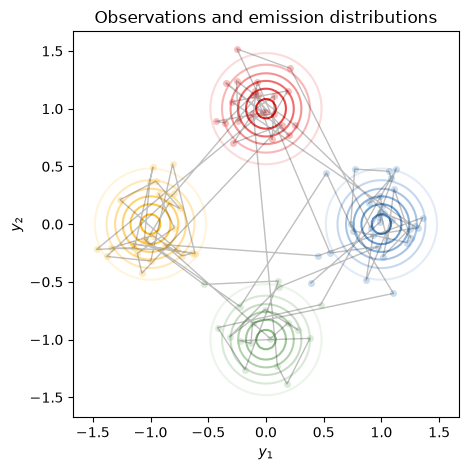

In [31]:
# Visualize emission distributions, observation sequence, and true_states 
plot_gaussian_hmm(hmm, true_params, true_observations, true_states, 
                  title="Observations and emission distributions")

In [32]:
def plot_gaussian_hmm_data(hmm, params, emissions, states, xlim=None, title = "Simulated data from an HMM"):
    """
    Create a time-series visualization of HMM emissions with hidden state background.
    
    Generates a multi-panel plot showing how observed emissions evolve over time,
    with background colors indicating the active hidden state at each time step.
    Each emission dimension gets its own subplot with observed data, expected means,
    and color-coded state information.
    
    Parameters
    ----------
    hmm : GaussianHMM
        A Gaussian Hidden Markov Model from dynamax.
    params : dict or NamedTuple
        HMM parameters containing emission means and other model parameters.
        Must include params.emissions.means with shape (num_states, emission_dim).
    emissions : array_like, shape (T, D)
        Sequence of D-dimensional observations over T time steps.
    states : array_like, shape (T,)
        Hidden state sequence corresponding to each time step.
        Values should be integers in range [0, hmm.num_states).
    xlim : tuple of (float, float), optional
        Time axis limits as (start, end). If None, uses full data range (0, T).
    title : str, optional
        Main plot title. Default is "Simulated data from an HMM".
        
    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object containing the plot.
    axs : array of matplotlib.axes.Axes
        Array of subplot axes, one per emission dimension.
    """
    num_timesteps = len(emissions)
    emission_dim = hmm.emission_dim
    means = params.emissions.means[states]
    lim = 1.05 * abs(emissions).max()

    # Plot the data superimposed on the generating state sequence
    fig, axs = plt.subplots(emission_dim, 1, sharex=True, figsize = (15, 5))
    
    for d in range(emission_dim):    
        ax_twin = axs[d].twinx()

        # Put state image axis in the background and data axis in the foreground
        ax_twin.set_zorder(0)
        axs[d].set_zorder(1)
        axs[d].patch.set_alpha(0)

        ax_twin.imshow(states[None, :], aspect="auto", interpolation="none", cmap=CMAP,
                      vmin=0, vmax=len(COLORS) - 1, extent=(0, num_timesteps, -1, 1), zorder=0)
        ax_twin.set_yticks([])
        axs[d].plot(emissions[:, d], "-k", zorder=3)
        axs[d].plot(means[:, d], ":k", zorder=4)
        axs[d].set_ylabel("$y_{{t,{} }}$".format(d+1))
        
    if xlim is None:
        plt.xlim(0, num_timesteps)
    else:
        plt.xlim(xlim)

    axs[-1].set_xlabel("Time steps")
    axs[0].set_title(title)
    plt.tight_layout()

    return fig, axs

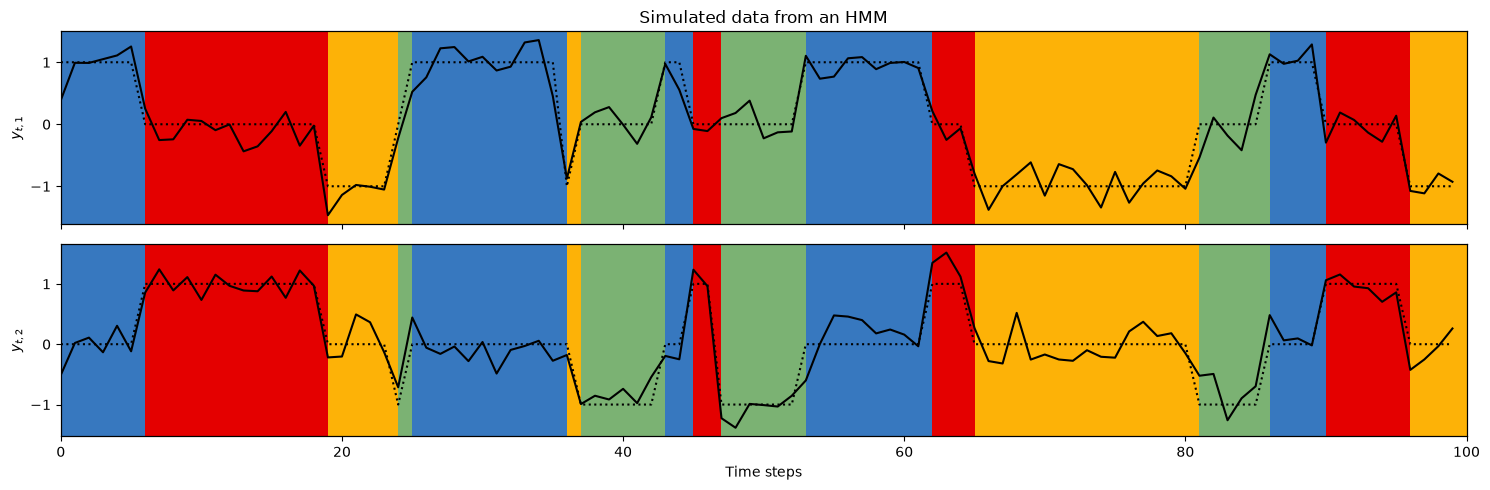

In [33]:
plot_gaussian_hmm_data(hmm, true_params, true_observations, true_states);

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<b>Task 1.5</b>: How does the HMM data change as you alter the transition matrix? Also, try changing the number of hidden states.
</div>

In [ ]:
"""
Starter code for you to change these parameters for task 1.5
"""

# Make an HMM and sample data and true underlying states
true_num_states_2 = 4  # CHANGE THIS!!!!!!!!!!!
observations_dim_2 = 2
hmm_2 = GaussianHMM(true_num_states_2, observations_dim_2)

# Use Jax to make a transition matrix.
# CHANGE THESE TOO!!!!!!! 
transition_matrix_2 = 0.8 * jnp.eye(true_num_states_2) \
    + 0.15 * jnp.roll(jnp.eye(true_num_states_2), 1, axis=1) \
    + 0.05 / true_num_states_2                                   

# Use Jax to set the the emission probabilities - mean and covariances
emission_means_2 = jnp.column_stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, true_num_states_2 + 1))[:-1],
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, true_num_states_2 + 1))[:-1],
    jnp.zeros((true_num_states_2, observations_dim_2 - 2)),
    ])
emission_covs_2 = jnp.tile(0.25**2 * jnp.eye(observations_dim), (true_num_states, 1, 1))

# Set the initial state distribution - change this to unequal probabilities.
initial_probs_2 = jnp.ones(true_num_states_2) / true_num_states_2

# Construct the HMM - this will be our ground truth 
true_params_2, _ = hmm_2.initialize(initial_probs=initial_probs_2,
                                transition_matrix=transition_matrix_2,
                                emission_means=emission_means_2,
                                emission_covariances=emission_covs_2)

# Sample your altered HMM
num_timesteps_2 = 100
key_2 = jr.split(jr.PRNGKey(0), 1)[0]
true_states_2, observations_2 = hmm_2.sample(key = key_2, params=true_params_2, num_timesteps=num_timesteps_2)

# Plot emissions and true_states
# plot_gaussian_hmm(...)

# plot_gaussian_hmm_data( ...)

## Use simulated data to estimate parameters of HMM

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p>So far, we have seen what the different parameters of our HMM do. <p>

<p>But most of the time, we don't actually have the luxury of knowing our model parameters when we start--we need to recover them from our data.</p>
</div>

In [36]:
# Random key
key = jr.PRNGKey(0)

# Instatiate a model.
# Lets start by assuming we know the number of states
true_num_states = 4
observations_dim = 2
model = GaussianHMM(true_num_states, observations_dim) 

# Initialize the model using the observations from our "ground truth" simulated data
params, props = model.initialize(key=key, method='kmeans', emissions=true_observations)

fit_params, train_lps = model.fit_em(params, props, true_observations, 
                                             num_iters=100, verbose=False)

In [ ]:
fit_params

ParamsGaussianHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.06666669, 0.06666671, 0.7333333 , 0.06666669, 0.06666669],      dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.8852867 , 0.00876527, 0.00876522, 0.08841757, 0.00876522],
       [0.00130616, 0.8515106 , 0.09274058, 0.04007624, 0.01436641],
       [0.00210653, 0.02317833, 0.80197734, 0.00210653, 0.17063136],
       [0.01562485, 0.14046124, 0.01704078, 0.8253194 , 0.00155376],
       [0.00194175, 0.02135928, 0.00194191, 0.15728801, 0.817469  ]],      dtype=float32)), emissions=ParamsGaussianHMMEmissions(means=Array([[ 0.105912  ,  0.9158876 ],
       [-0.94546604, -0.02565858],
       [-0.01765645, -0.9299992 ],
       [ 0.00186363,  1.1074762 ],
       [ 0.94599056,  0.02545687]], dtype=float32), covs=Array([[[1.4428747e-05, 1.3805234e-06],
        [1.3805234e-06, 2.6294125e-05]],

       [[6.0656700e-02, 3.3279818e-03],
        [3.3279818e-03, 5.9831776e-02]],

       [[3.348090

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<b>Task 1.6</b>:  Visualize the transition matrix for the model we just fit.

Hint: Use <i>fit_params.transitions.transition_matrix</i>

Does it look like you would expect?
</div>

In [1]:
# Blank coding cell to work out Task 1.6


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Reconstructing the transition matrix for a known model is, perhaps, too easy a problem. In most cases we won't have anywhere near this much prior information about the HMM we are trying to reconstruct. What is, for example, the true number of states in the mouse? How do we assess the quality of fit? 
</div>

## Cross Validation

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>
Cross-validation is a technique for estimating how well a model will perform on new, unseen data by repeatedly training it on one subset of the data and evaluating it on another.
</p>

<p>
In this example, we will use cross-validation to choose the number of states. To make this work, let's go ahead and simulate three "chunks" of data from our ground truth model. In "real life," you will do this by splitting your data up. Here, we have the artificial luxury of simulating seperate chunks. 

</div>


In [38]:
# Separating data into batches
num_train_batches = 3
num_timesteps= 100

# Simulate 3 sets of data from the mode
train_key = jr.split(jr.PRNGKey(0), 3)
train_true_states = np.zeros((num_train_batches, num_timesteps)).astype(int)
train_observations = np.zeros((num_train_batches, num_timesteps,  observations_dim))
for k in range(num_train_batches):
    train_true_states[k], train_observations[k] = hmm.sample(key = train_key[k], params=true_params, num_timesteps=num_timesteps)

In [39]:
# ------------------------------------------------------------------
# Split the data into training and validation sets.
# Here, we use the third sequence for validation and train on the
# remaining two sequences.
# ------------------------------------------------------------------
y_val = train_observations[2]
y_train = jnp.concatenate(
    [train_observations[0], train_observations[1]],
    axis=0
)

# ------------------------------------------------------------------
# Initialize a Gaussian HMM.
# ------------------------------------------------------------------
num_states = 5
observation_dims = 2
model = GaussianHMM(
    num_states,
    observation_dims,
    transition_matrix_stickiness=10.
)

k_key = jr.PRNGKey(0)

# Initialize the model parameters using K-means
params, props = model.initialize(
    key=k_key,
    method="kmeans",
    emissions=y_train
)

# ------------------------------------------------------------------
# Fit the model to the training data using the EM algorithm.
# ------------------------------------------------------------------
fit_params, train_lps = model.fit_em(
    params,
    props,
    y_train,
    num_iters=100,
    verbose=False,
)

# ------------------------------------------------------------------
# Evaluate the fitted model on both the training and validation sets.
# Report the average log-likelihood per observation so that scores
# are comparable across datasets of different sizes.
# ------------------------------------------------------------------
train_lp_per_obs = train_lps[-1] / y_train.shape[0]
val_lp_per_obs = (
    model.marginal_log_prob(fit_params, y_val)
    / y_val.shape[0]
)

print(f"Training log-likelihood per observation: {train_lp_per_obs:.2f}")
print(f"Validation log-likelihood per observation: {val_lp_per_obs:.2f}")

Training log-likelihood per observation: -0.55
Validation log-likelihood per observation: -0.79


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
<p> Here are some functions that "splits" above simulated data to fit evaluate models.
    
</div>

In [40]:
def fit_model_fold(model, params, props, y_train, y_val, num_iters=100):
    """
    Train a model on training data and evaluate on validation data for one cross-validation fold.
    
    Parameters
    ----------
    model : HMM or similar probabilistic model
        The model object with fit_em() and marginal_log_prob() methods
    params : dict or similar
        Initial model parameters (means, covariances, transition probabilities, etc.)
    props : dict or similar  
        Additional model properties or metadata from initialization
    y_train : array-like, shape (num_sequences, num_timesteps, obs_dim)
        Training observations for this fold. Multiple sequences concatenated along
        the first axis.
    y_val : array-like, shape (num_timesteps, obs_dim)
        Validation observations for this fold. Single sequence to evaluate on.
    num_iters : int, default=100
        Maximum number of EM iterations for training
        
    Returns
    -------
    float
        Marginal log-likelihood of the validation data given the trained model.
        Higher values (less negative) indicate better model fit and generalization.
    """

    # Fit on the training batches, evaluate on the held-out batch
    fit_params, train_lps = model.fit_em(params, props, y_train,
                                         inputs=None, num_iters=num_iters, verbose=False)
    return model.marginal_log_prob(fit_params, y_val)
    

In [41]:
def cross_validate_model(model, key, train_observations, num_iters=100,):
    """
    Perform k-fold cross-validation on a HMM or other probabilistic sequence model.
    
    This function performs k-fold cross-validation where k equals the number of
    batches in train_observations.

    Note that the function overrides fits on the passed model object on each fold.
    Use "copy/deepcopy" to protect a model you do not wish to override.
    
    Parameters
    ----------
    model : HMM or similar probabilistic model
        The model object to be cross-validated. Must have initialize(), fit_em(),
        and marginal_log_prob() methods. A deep copy is created for each fold.
    key : jax.random.PRNGKey
        Random key for reproducible initialization. Different keys are derived
        for each fold using jax.random.fold_in().
    train_observations : array-like, shape (num_batches, num_timesteps, obs_dim)
        Batched observation sequences. Each batch along axis 0 becomes a validation
        fold, with remaining batches used for training that fold.
    num_iters : int, default=100
        Maximum number of EM iterations for training each fold.
        
    Returns
    -------
    mean_val_ll : float
        Mean validation log-likelihood across all folds. This is the primary
        metric for model performance - higher values indicate better generalization.
    val_lls : ndarray, shape (num_batches,)
        Individual validation log-likelihood for each fold. Useful for assessing
        consistency of performance across folds.
    """
    
    num_train_batches = int(train_observations.shape[0])

    val_lls = np.zeros(num_train_batches, dtype=float)

    for k in range(num_train_batches):
        # held-out validation batch
        y_val = train_observations[k]
        # all other batches concatenated along batch axis
        y_train = jnp.concatenate([train_observations[:k], train_observations[k+1:]], axis=0)

        # Each fold gets a radom key
        k_key = jr.fold_in(key, k)
        # Make the model for this fold
        params, props = model.initialize(key=k_key, method='kmeans', emissions=y_train)
        
        val_lls[k] = float(fit_model_fold(model, params, props, y_train, y_val, num_iters))
        
    return float(val_lls.mean()), val_lls

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
<p> Now lets cross validate!
    
</div>

In [42]:
# An example for 
this_num_states = 4
observation_dims = 2
cv_model = GaussianHMM(this_num_states, observation_dims, transition_matrix_stickiness=10.) 
cv_key = jr.PRNGKey(0)
mean_ll,fold_lls = cross_validate_model(cv_model,cv_key,train_observations)
print(mean_ll)
print(fold_lls)

-80.5784174601237
[-65.66809845 -97.47210693 -78.595047  ]


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
<p> On its own, this log likelihood data isn't super useful. Log likelihood, for example, scales with the number of samples, so its tricky to compare accross datasets.

<p> Where it can be useful, however, is in comparing models that are fit on the same data. 

<p> Lets go ahead and try this. We will fit models with different number of states, then use the log likelihoods to evalue which model is "best."</p>


</div>

# Fit models with different numbers of states to identify "best" model

In [43]:
# Make a range of Gaussian HMMs
all_num_states = list(range(2, 10))

avg_val_lls = np.zeros(len(all_num_states))
all_val_lls = np.zeros((len(all_num_states),3))

for ii,this_num_states  in enumerate(all_num_states):
    print(f"fitting model with {this_num_states} states")
    this_model = GaussianHMM(this_num_states, observation_dims, transition_matrix_stickiness=10.) 
    mean_ll,fold_lls = cross_validate_model(this_model,cv_key,train_observations)
    avg_val_lls[ii] = mean_ll
    all_val_lls[ii,:] = fold_lls


fitting model with 2 states
fitting model with 3 states
fitting model with 4 states
fitting model with 5 states
fitting model with 6 states
fitting model with 7 states
fitting model with 8 states
fitting model with 9 states


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> Lets plot up the average validation log-likelihood and discuss with your neighbor the implications of this curve shape? If you didn't know how many true states there where, how would you decide when to stop adding states? Will this lesson generalize to other types of data?
</div>

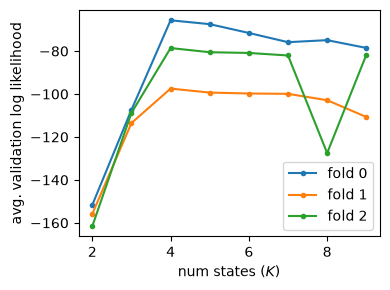

In [44]:
plt.figure(figsize = (4, 3))
for cv in range(num_train_batches):
    plt.plot(all_num_states, np.array(all_val_lls)[:, cv], '.-', label = f'fold {cv}')
plt.legend()
plt.xlabel("num states ($K$)")
plt.ylabel("avg. validation log likelihood")
plt.tight_layout()

> **How should we choose the right number of states?**
>
> There's no single "right" answer for how to choose the number of states, but reasonable heuristics include:
>
> - picking $K$ that has the highest average validation log likelihood
> - picking $K$ where the average validation log likelihood stops increasing by a minimum amount
> - picking $K$ with a hypothesis test for increasing mean
> - picking $K$ consistent with the predictability-computability-stability (PCS) framework.

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> Here, we'll just choose the number of states with the highest average validation log likelihood to determine the best number of states for our HMM.</p>
<p> Note that this is "OK" because our folds are all the same size, so this falls into the special case where log likelihoods are safe to compare!</p>
<p> Did we do a good job of recapitulating our ground truth? </p>
</div>

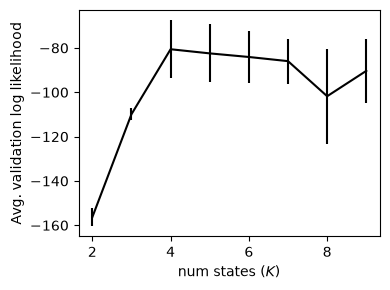

In [45]:
plt.figure(figsize = (4, 3))
std_dev= np.nanstd(all_val_lls, axis= 1)
plt.errorbar(all_num_states, avg_val_lls, yerr = std_dev , color='k')
plt.xlabel("num states ($K$)")
plt.ylabel("Avg. validation log likelihood")
plt.tight_layout()

In [46]:
best_num_states = all_num_states[jnp.argmax(jnp.stack(avg_val_lls))]
print("best number of states:", best_num_states)

best number of states: 4


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Now that we have a guess as to the "best" number of states, we can find the most likely state any any given instance in time.

In [47]:
# Fit the model
key = jr.PRNGKey(0)
test_hmm = GaussianHMM(best_num_states, observations_dim, transition_matrix_stickiness=10.)
params, props = test_hmm.initialize(key=key, method="kmeans", emissions=true_observations)
params, lps = test_hmm.fit_em(params, props, train_observations, num_iters=100)

<div><progress max="100" value="100"></progress> 100.00% [100/100 00:01&lt;00:00]</div>

In [48]:
# Predict states
most_likely_states = test_hmm.most_likely_states(params, true_observations)


(<Figure size 1500x500 with 4 Axes>,
 array([<Axes: title={'center': 'Estimated states'}, ylabel='$y_{t,1 }$'>,
        <Axes: xlabel='Time steps', ylabel='$y_{t,2 }$'>], dtype=object))

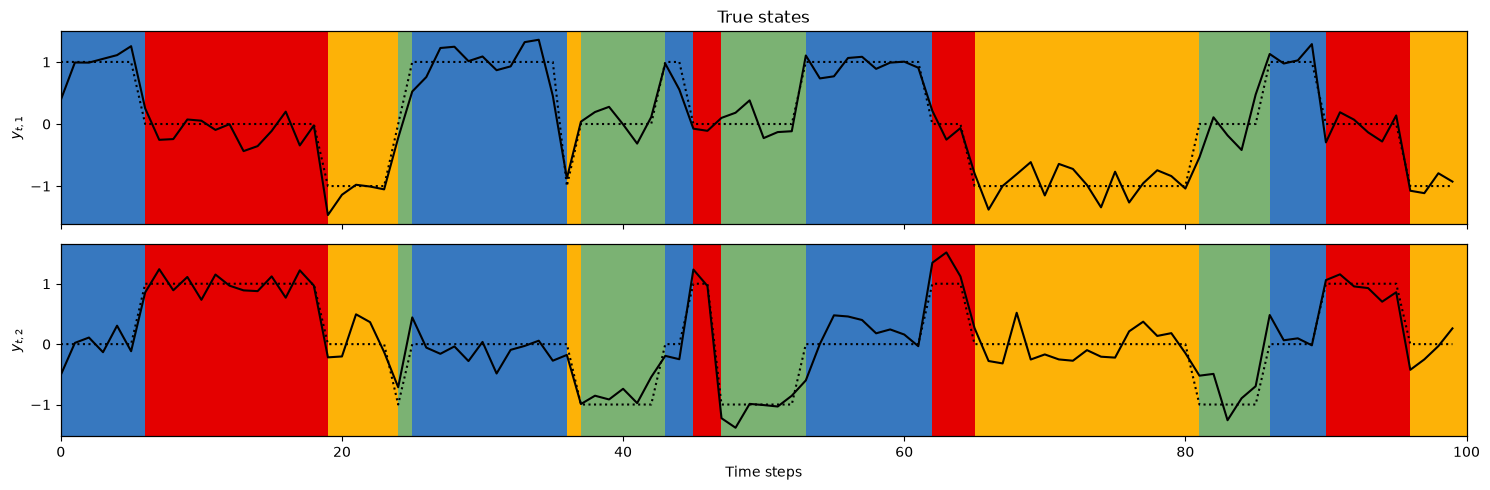

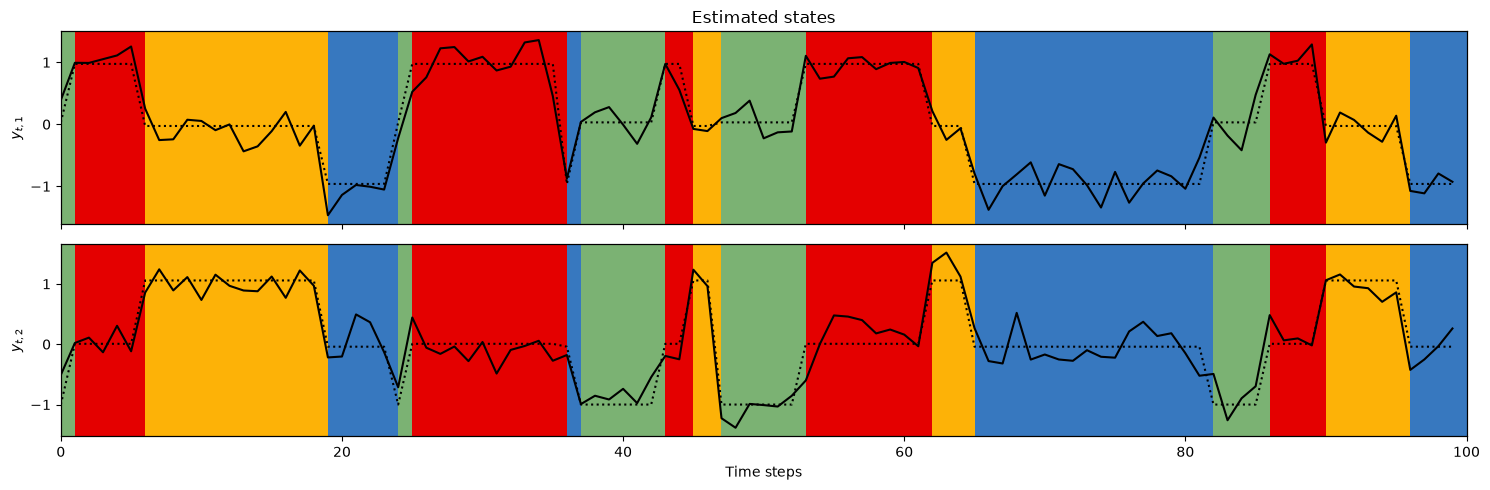

In [49]:
# Plot true states
plot_gaussian_hmm_data(hmm, true_params, true_observations, true_states, title = 'True states')

# Plot inferred states
plot_gaussian_hmm_data(test_hmm, params, true_observations, most_likely_states, title = 'Estimated states')


## State determination in Dynamic Routing data

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<p> We now kind of get a hang of HMM. So, let's take what we've done above and apply it to the behavior variables from the previous workshop to automatically detect states in our mice! Now, we have the capability to incorporate a multi-dimensional dataset to inform our state boundaries. 
<p> To accomplish this goal, we will fit our data to a Gaussian HMM. 
    
<p> To complement our states from the previous workshop, lets extract the behavior states using only behavior data, that is, pupil size, running speed and facial features.
</div>

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
Our first step will be to cast our data as <b>JAX</b> arrays

In [50]:
# For this model, it's important that the data is converted into a *JAX* array
observations = jnp.array(behavior_df.values)
num_trials, num_dimensions = observations.shape

In [51]:
behavior_df.head(5)

,ear,nose,jaw,whiskers,running_speed,pupil_area
0,0.133465,-0.267715,0.373126,0.332965,23.099572,6959.737914
1,0.081053,-0.913409,-0.676667,-0.260415,37.117426,3239.302947
2,1.924991,-1.614430,-0.709831,-0.851483,22.501092,3004.855885
3,2.449824,-1.242968,-0.236218,-0.449283,35.196670,2842.635555
4,-0.512931,-0.255123,0.428931,0.185256,64.799488,3439.184146


In [52]:
observations[:5,:]

Array([[ 1.3346495e-01, -2.6771528e-01,  3.7312567e-01,  3.3296451e-01,
         2.3099571e+01,  6.9597378e+03],
       [ 8.1053384e-02, -9.1340941e-01, -6.7666662e-01, -2.6041469e-01,
         3.7117428e+01,  3.2393030e+03],
       [ 1.9249909e+00, -1.6144296e+00, -7.0983142e-01, -8.5148305e-01,
         2.2501093e+01,  3.0048560e+03],
       [ 2.4498243e+00, -1.2429684e+00, -2.3621778e-01, -4.4928256e-01,
         3.5196671e+01,  2.8426355e+03],
       [-5.1293093e-01, -2.5512287e-01,  4.2893115e-01,  1.8525587e-01,
         6.4799492e+01,  3.4391841e+03]], dtype=float32)

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF;">

<p>You will notice that all of these data are in very different values. We can use <b>StandardScaler</b> from <b>sklearn</b> to help us deal with these very differently scaled data by Z-scoring them.</p>

<p>This is especially important for HMMs: if features are on very different scales, the model will be dominated by high-variance features and fail to learn meaningful structure from the rest.</p>

</div>

In [53]:
# First scale the dimensions of the data to be normalized
scaler = StandardScaler()    
observations = scaler.fit_transform(observations)
observations[:5,:]

array([[-0.20931347,  0.09958822,  0.78840864,  0.5580375 , -1.4787284 ,
         7.8555555 ],
       [-0.2502978 , -0.92428994, -1.714549  , -0.98727906, -0.45913756,
         0.47742647],
       [ 1.1916078 , -2.0358984 , -1.7936218 , -2.5265777 , -1.5222589 ,
         0.01248611],
       [ 1.6020123 , -1.4468721 , -0.66441286, -1.479141  , -0.5988441 ,
        -0.30921915],
       [-0.71477634,  0.11955602,  0.9214623 ,  0.1733651 ,  1.5543214 ,
         0.8738179 ]], dtype=float32)

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
Finally, lets parameterize our cross validation. 

</div>

In [54]:
# Finally, lets parameterize our cross validiation
n_batches = 3
n_steps = num_trials - (num_trials % n_batches)
batched_observations = observations[:n_steps, :].reshape(n_batches, -1, observations.shape[1])
batch_size = batched_observations.shape[1]

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
One very quick mathematical aside: <b>Dynamax</b> can't handle num_states = 1 (a simple way of thinking about this is that a one state model isn't really a mixture of states, is it?). But what if our mouse is in the same state the whole time?

The good news is that is is pretty straightforward to use a maximum likelihood estimator to compute the log likelihood for a single gaussian fit to the data. Here is a function that uses <b>JAX</b> to do this. 

In [55]:
from jax.scipy.stats import multivariate_normal as mvn

def _gaussian_mle_loglik(y_train, y_val, eps=1e-6):
    """
    Compute the log-likelihood of validation data under a multivariate Gaussian
    fitted via maximum likelihood estimation on training data.
    
    Fits a multivariate Gaussian distribution to the training data using MLE
    (sample mean and unbiased sample covariance), then evaluates the total
    log-likelihood of the validation data under this fitted distribution.
    
    Parameters
    ----------
    y_train : array_like, shape (B_train, T, D) or (N, D)
        Training data. If 3D, represents B_train batches of T timesteps with
        D-dimensional observations. If 2D, represents N observations with
        D dimensions. Will be flattened to (N_train, D) for MLE fitting.
    y_val : array_like, shape (T, D) or (B_val, T, D)
        Validation data to evaluate log-likelihood on. If 3D, will be flattened
        to (N_val, D). If 2D, used as-is.
    eps : float, default=1e-6
        Regularization parameter added to diagonal of covariance matrix for
        numerical stability (prevents singular matrices).
    
    Returns
    -------
    float
        Total log-likelihood of all validation samples under the fitted
        multivariate Gaussian distribution.
        
    """

    # Flatten batch/time for MLE
    Yt = jnp.reshape(y_train, (-1, y_train.shape[-1]))  # (N_train, D)
    mu = jnp.mean(Yt, axis=0)                           # (D,)
    # Unbiased sample cov; regularize for numeric stability
    Yc = Yt - mu
    # (D,D)
    Sigma = (Yc.T @ Yc) / jnp.maximum(Yt.shape[0] - 1, 1)
    Sigma = Sigma + eps * jnp.eye(Sigma.shape[0], dtype=Sigma.dtype)

    # Evaluate log-likelihood on validation
    if y_val.ndim == 3:  # (B_val, T, D)
        Yv = jnp.reshape(y_val, (-1, y_val.shape[-1]))
    else:                # (T, D)
        Yv = y_val
    ll = jnp.sum(mvn.logpdf(Yv, mu, Sigma))
    return float(ll)


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
We now need to update our cross validation code to handle this new case.

In [56]:
def cross_validate_model(model, key, train_observations, num_iters=100):
    """
    This function is the same as the one above, 
    but with functionality to handle 1-state models
    """
    num_train_batches = int(train_observations.shape[0])
    val_lls = np.zeros(num_train_batches, dtype=float)

    for k in range(num_train_batches):
        y_val = train_observations[k]
        y_train = jnp.concatenate([train_observations[:k], train_observations[k+1:]], axis=0)

        if model.num_states == 1:
            # Bypass Dynamax EM/prior for 1-state; use Gaussian MLE baseline.
            val_lls[k] = _gaussian_mle_loglik(y_train, y_val)
            continue

        # K >= 2: normal Dynamax path
        k_key = jr.fold_in(key, k)
        params, props = model.initialize(key=k_key, method='kmeans', emissions=y_train)
        val_lls[k] = float(fit_model_fold(model, params, props, y_train, y_val, num_iters))

    return float(val_lls.mean()), val_lls

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
Great! We are now ready for the <b>"Main Event"</b> some model fitting with <b>real</b> data.

In [57]:
# Random key so things dont change each time we run the cell
key = jr.PRNGKey(0)

# Number of states to test
num_states_range = np.arange(1, 9)

# Define empty lists so that we have place to put our data.
avg_test_lls = np.empty(len(num_states_range))
all_test_lls = np.empty([len(num_states_range),n_batches])
std_test_lls = np.empty(len(num_states_range))

for ii,num_states in enumerate(num_states_range):
    hmm = GaussianHMM(num_states, batched_observations.shape[-1], transition_matrix_stickiness=5)
    
    print(f"\n{'='*40}\nTraining model with {num_states} state(s)\n{'='*40}")
    
    avg_ll, lls = cross_validate_model(
        hmm, key, batched_observations, num_iters=100
    )
    avg_test_lls[ii] = avg_ll
    all_test_lls[ii,:] = lls.flatten()
    std_test_lls[ii] = np.std(all_test_lls[ii,:])


Training model with 1 state(s)

Training model with 2 state(s)

Training model with 3 state(s)

Training model with 4 state(s)

Training model with 5 state(s)

Training model with 6 state(s)

Training model with 7 state(s)

Training model with 8 state(s)


<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Lets plot the results of our cross validation to see number of states yeilds the best fit.

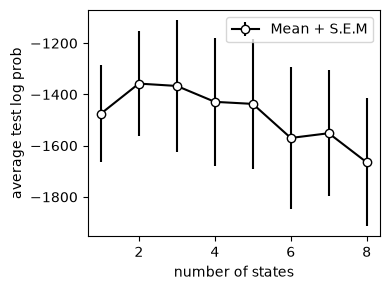

In [58]:
plt.figure(figsize = (4, 3))
plt.errorbar(num_states_range, avg_test_lls, yerr = np.array(std_test_lls)/np.sqrt(n_batches), 
             mfc = 'w', color = 'k', marker = 'o')
plt.legend(['Mean + S.E.M'])
plt.xlabel("number of states")
plt.ylabel("average test log prob")
plt.tight_layout()

In [59]:
key = jr.PRNGKey(0)
number_of_states = np.argmax(avg_test_lls) + 1

print(f"Best number of states: {number_of_states}")
final_hmm = GaussianHMM(number_of_states, num_dimensions, transition_matrix_stickiness=5)
params, param_props = final_hmm.initialize(key=key, method="kmeans", emissions=jnp.array(observations))
params, lps = final_hmm.fit_em(params, param_props, jnp.array(observations), num_iters=500)


Best number of states: 2


<div><progress max="500" value="500"></progress> 100.00% [500/500 01:27&lt;00:00]</div>

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> Lets plot the inferred states from the "best" model we just fit </p>

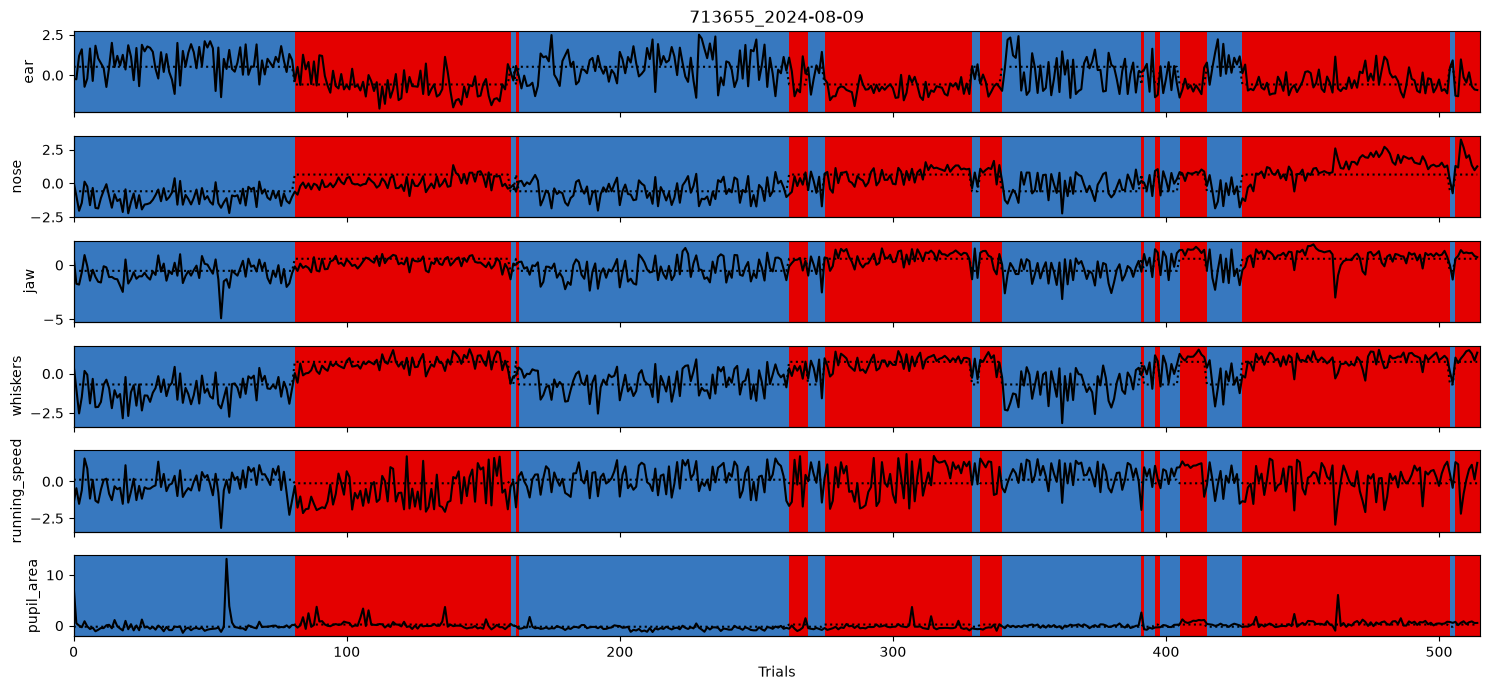

In [60]:
# Find the most likely discrete states given the learned model parameters
most_likely_states = final_hmm.most_likely_states(params, observations)
fig, axs = plot_gaussian_hmm_data(final_hmm, params, observations, most_likely_states, title = f'{session_id}')

# Formatting 
xticks = axs[0].get_xticks().astype(int)[:-1]
for n, ax in enumerate(axs):
    ax.set_ylabel(f'{behavior_df.keys()[n]}')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axs[-1].set_xlabel('Trials')

fig.set_size_inches(15,7)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
Finally, lets bring this full circle. Lets plot the result of our model relative to our the thresholding method we used at the beginning of this tutorial. Did we uncover anything new?

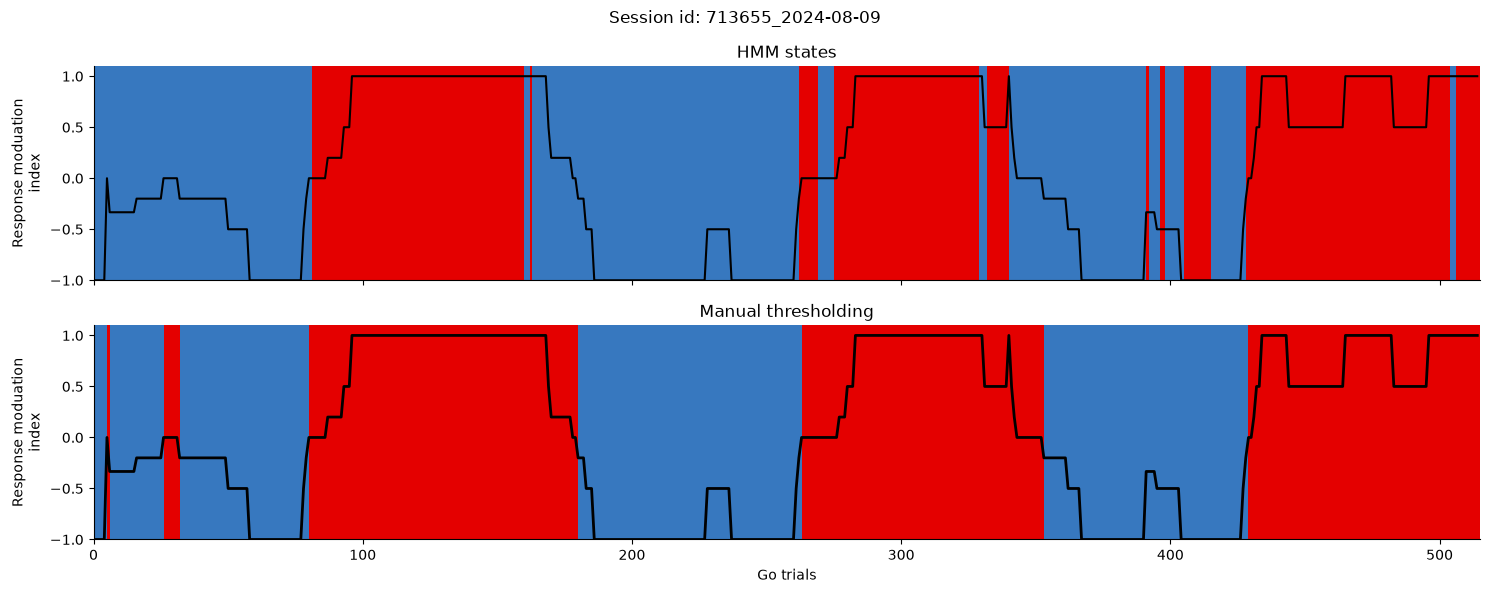

In [61]:
# Plot state boundaries for HMM fit
fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
hmm_states = most_likely_states
ax[0].imshow(hmm_states[None, :], aspect="auto", interpolation="none", cmap=CMAP, vmin=0, vmax=len(COLORS) - 1,  extent=[0, len(hmm_states), -1, 1.1]  )
ax[0].plot(trials["response_modulation_index"], color = 'k', label = 'resp rate')

# Plot states from manual threshold
ax[1].imshow(behavioral_state.values[None, :], aspect="auto", interpolation="none", cmap=CMAP, vmin=0, vmax=len(COLORS) - 1,  extent=[0, len(behavioral_state), -1, 1.1]  )
ax[1].plot(trials["response_modulation_index"], color = 'k', lw = 2)

# Formatting 
ax[0].set_title('HMM states')
ax[1].set_title('Manual thresholding')
ax[1].set_xlabel("Go trials")
xticks = ax[0].get_xticks().astype(int)[:-1]
for j in range(2): 
    ax[j].set_ylabel('Response moduation\nindex')
    handles, labels = ax[j].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax[j].spines["top"].set_visible(False)
    ax[j].spines["right"].set_visible(False)
plt.suptitle(f'Session id: {session_id}')
plt.tight_layout()

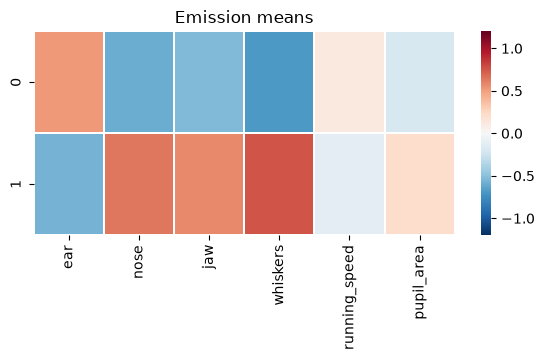

In [62]:
plt.figure(figsize = (5.8, 3.7))
sns.heatmap(params.emissions.means, xticklabels = behavior_df.keys(), yticklabels= np.arange(number_of_states), cmap = 'RdBu_r', linewidths=0.2, vmax = 1.2, vmin = -1.2)
plt.title('Emission means')
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
This brings us to the end of this session. In the homework you will get a chance to dive into these state definitions more deeply and to ask whether neural population decoding varies between states. 
</div>